# Garbage Classification with TensorFlow

This notebook builds a TensorFlow/Keras CNN to classify images from the `garbage_dataset` folder into the three available classes: `dry_waste`, `electronic_waste`, and `wet_waste`.


In [55]:
import io
import random
from collections import Counter
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from IPython.display import display
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = Path("garbage_dataset")
IMG_SIZE = 192
BATCH_SIZE = 16
NUM_EPOCHS = 28
LEARNING_RATE = 8e-4
AUTOTUNE = tf.data.AUTOTUNE

print(f"TensorFlow version: {tf.__version__}")


TensorFlow version: 2.21.0


In [64]:
class_names = sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()])
num_classes = len(class_names)
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
electronic_idx = class_to_idx.get("electronic_waste", 1)

image_paths = []
image_labels = []
for class_name in class_names:
    class_dir = DATA_DIR / class_name
    for image_path in sorted(class_dir.glob("*")):
        if image_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
            image_paths.append(str(image_path))
            image_labels.append(class_to_idx[class_name])

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    image_labels,
    test_size=0.30,
    random_state=SEED,
    stratify=image_labels,
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels,
)


def oversample_with_targets(paths, labels, boosts=None, seed=SEED):
    boosts = boosts or {}
    rng = random.Random(seed)
    grouped = {}
    for p, y in zip(paths, labels):
        grouped.setdefault(y, []).append(p)

    max_count = max(len(items) for items in grouped.values())
    out_paths, out_labels = [], []

    for class_idx, items in grouped.items():
        target = int(max_count * boosts.get(class_idx, 1.0))
        target = max(target, len(items))

        if len(items) < target:
            extra = [rng.choice(items) for _ in range(target - len(items))]
            items = items + extra

        rng.shuffle(items)
        out_paths.extend(items)
        out_labels.extend([class_idx] * len(items))

    merged = list(zip(out_paths, out_labels))
    rng.shuffle(merged)
    out_paths, out_labels = zip(*merged)
    return list(out_paths), list(out_labels)


train_paths, train_labels = oversample_with_targets(
    train_paths,
    train_labels,
    boosts={electronic_idx: 1.6},
)


def decode_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, tf.cast(label, tf.int32)


def random_zoom(image, min_scale=0.82, max_scale=1.0):
    scale = tf.random.uniform([], min_scale, max_scale)
    new_h = tf.cast(scale * IMG_SIZE, tf.int32)
    new_w = tf.cast(scale * IMG_SIZE, tf.int32)
    crop = tf.image.random_crop(image, size=[new_h, new_w, 3])
    return tf.image.resize(crop, [IMG_SIZE, IMG_SIZE])


def base_augment(image):
    image = tf.image.random_flip_left_right(image, seed=SEED)
    image = random_zoom(image, min_scale=0.82, max_scale=1.0)

    # Mild color jitter for all classes.
    image = tf.image.random_brightness(image, max_delta=0.12)
    image = tf.image.random_contrast(image, lower=0.85, upper=1.15)
    image = tf.image.random_saturation(image, lower=0.85, upper=1.15)
    image = tf.image.random_hue(image, max_delta=0.03)

    # Small gaussian noise improves robustness to sensor/compression artifacts.
    noise = tf.random.normal(tf.shape(image), stddev=0.02)
    image = image + noise
    return tf.clip_by_value(image, 0.0, 1.0)


def extra_electronic_augment(image):
    # Stronger augmentations for the underperforming electronic_waste class.
    image = random_zoom(image, min_scale=0.75, max_scale=0.95)
    image = tf.image.random_contrast(image, lower=0.75, upper=1.25)
    image = tf.image.random_saturation(image, lower=0.75, upper=1.25)
    image = tf.image.random_hue(image, max_delta=0.05)
    return tf.clip_by_value(image, 0.0, 1.0)


def augment(image, label):
    image = base_augment(image)
    image = tf.cond(
        tf.equal(label, tf.cast(electronic_idx, tf.int32)),
        lambda: extra_electronic_augment(image),
        lambda: image,
    )
    return image, label


def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds = make_dataset(val_paths, val_labels, training=False)
test_ds = make_dataset(test_paths, test_labels, training=False)

print("Classes:", class_names)
print(f"Train / Val / Test: {len(train_paths)} / {len(val_paths)} / {len(test_paths)}")
print("Train class distribution after oversampling:", dict(Counter(train_labels)))
print("Electronic class index:", electronic_idx)


Classes: ['dry_waste', 'electronic_waste', 'wet_waste']
Train / Val / Test: 212 / 36 / 36
Train class distribution after oversampling: {1: 94, 0: 59, 2: 59}
Electronic class index: 1


In [61]:
regularizer = tf.keras.regularizers.l2(1e-4)


def conv_bn_act(x, filters, kernel_size=3, strides=1, dropout_rate=0.0):
    x = tf.keras.layers.Conv2D(
        filters,
        kernel_size,
        strides=strides,
        padding="same",
        use_bias=False,
        kernel_regularizer=regularizer,
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("swish")(x)
    if dropout_rate > 0:
        x = tf.keras.layers.Dropout(dropout_rate)(x)
    return x


def residual_block(x, filters, downsample=False, dropout_rate=0.0):
    stride = 2 if downsample else 1
    shortcut = x

    x = conv_bn_act(x, filters, strides=stride)
    x = tf.keras.layers.Conv2D(
        filters,
        3,
        strides=1,
        padding="same",
        use_bias=False,
        kernel_regularizer=regularizer,
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)

    if downsample or shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(
            filters,
            1,
            strides=stride,
            padding="same",
            use_bias=False,
            kernel_regularizer=regularizer,
        )(shortcut)
        shortcut = tf.keras.layers.BatchNormalization()(shortcut)

    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.Activation("swish")(x)
    if dropout_rate > 0:
        x = tf.keras.layers.Dropout(dropout_rate)(x)
    return x


inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = conv_bn_act(inputs, 32, kernel_size=3)
x = conv_bn_act(x, 32, kernel_size=3)

x = residual_block(x, 64, downsample=True, dropout_rate=0.10)
x = residual_block(x, 64, downsample=False, dropout_rate=0.10)

x = residual_block(x, 128, downsample=True, dropout_rate=0.15)
x = residual_block(x, 128, downsample=False, dropout_rate=0.15)

x = residual_block(x, 192, downsample=True, dropout_rate=0.20)
x = residual_block(x, 192, downsample=False, dropout_rate=0.20)

x = conv_bn_act(x, 256, kernel_size=3, dropout_rate=0.20)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation="swish", kernel_regularizer=regularizer)(x)
x = tf.keras.layers.Dropout(0.35)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs, name="garbage_residual_cnn_v2")

lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=LEARNING_RATE,
    first_decay_steps=120,
    t_mul=1.5,
    m_mul=0.9,
    alpha=1e-2,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "garbage_residual_cnn_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 192, 192,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_73 (Conv2D)  │ (None, 192, 192,  │        864 │ input_layer_19[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 192, 192,  │        128 │ conv2d_73[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_30       │ (None, 192, 192,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_74 (Conv2D)  │ (None, 192, 192,  │      9,216 │ activation_30[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 192, 192,  │        128 │ conv2d_74[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_31       │ (None, 192, 192,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_75 (Conv2D)  │ (None, 96, 96,    │     18,432 │ activation_31[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        256 │ conv2d_75[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_32       │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_76 (Conv2D)  │ (None, 96, 96,    │     36,864 │ activation_32[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_77 (Conv2D)  │ (None, 96, 96,    │      2,048 │ activation_31[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        256 │ conv2d_76[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        256 │ conv2d_77[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 96, 96,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_33       │ (None, 96, 96,    │          0 │ add_12[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_37          │ (None, 96, 96,    │          0 │ activation_33[0]

 Total params: 2,424,419 (9.25 MB)

 Trainable params: 2,419,939 (9.23 MB)

 Non-trainable params: 4,480 (17.50 KB)

In [62]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_garbage_cnn.keras", monitor="val_accuracy", save_best_only=True),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=NUM_EPOCHS,
    callbacks=callbacks,
)

model = tf.keras.models.load_model("best_garbage_cnn.keras")

train_metrics = model.evaluate(train_ds, verbose=0)
val_metrics = model.evaluate(val_ds, verbose=0)
print(f"Train loss / acc: {train_metrics[0]:.4f} / {train_metrics[1]:.4f}")
print(f"Val loss / acc: {val_metrics[0]:.4f} / {val_metrics[1]:.4f}")


Epoch 1/28
12/12 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.5198 - loss: 1.3184 - val_accuracy: 0.3611 - val_loss: 1.3081
Epoch 2/28
12/12 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.5989 - loss: 1.3287 - val_accuracy: 0.3056 - val_loss: 2.2806
Epoch 3/28
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.5876 - loss: 1.2055 - val_accuracy: 0.4722 - val_loss: 3.0316
Epoch 4/28
12/12 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.6102 - loss: 1.0675 - val_accuracy: 0.5000 - val_loss: 3.5172
Epoch 5/28
12/12 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.5989 - loss: 1.0863 - val_accuracy: 0.5833 - val_loss: 2.5102
Epoch 6/28
12/12 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.6723 - loss: 1.0408 - val_accuracy: 0.5000 - val_loss: 2.2977
Epoch 7/28
12/12 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.6667 - loss: 0.9794 - val_accuracy: 0.5000 - val_loss: 1.7776
Epoch 8/28
12/12 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.7062 - loss: 1.0174 - val_accuracy: 0.4722 - val_loss:

Test loss / accuracy: 2.9887 / 0.5278
Test classification report:
                  precision    recall  f1-score   support

       dry_waste       0.60      0.69      0.64        13
electronic_waste       0.00      0.00      0.00        11
       wet_waste       0.48      0.83      0.61        12

        accuracy                           0.53        36
       macro avg       0.36      0.51      0.42        36
    weighted avg       0.38      0.53      0.43        36



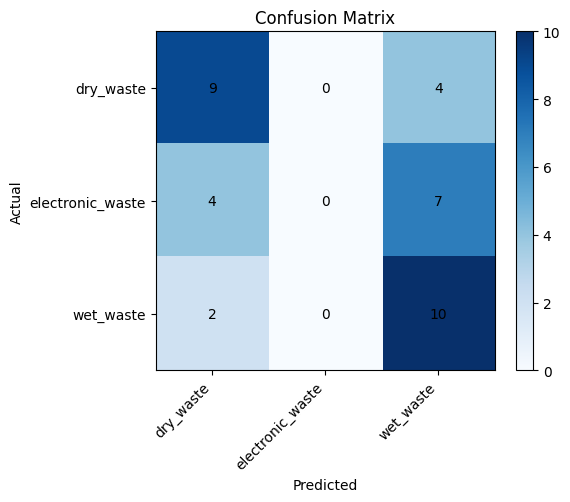

Sample image: garbage_dataset\dry_waste\000075.jpg
Sample prediction: ('dry_waste', 1.0)


In [63]:
def tta_predict_batch(images):
    variants = [
        images,
        tf.image.flip_left_right(images),
        tf.image.adjust_brightness(images, 0.05),
        tf.image.adjust_contrast(images, 1.05),
    ]
    preds = [model.predict(v, verbose=0) for v in variants]
    return np.mean(preds, axis=0)


test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
print(f"Test loss / accuracy: {test_loss:.4f} / {test_accuracy:.4f}")

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = tta_predict_batch(images)
    y_pred.extend(np.argmax(predictions, axis=1).tolist())
    y_true.extend(labels.numpy().tolist())

print("Test classification report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()


def predict_image(image_path: str):
    with Image.open(image_path) as image:
        image = image.convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        arr = np.asarray(image, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)
    probs = tta_predict_batch(tf.convert_to_tensor(arr, dtype=tf.float32))[0]
    idx = int(np.argmax(probs))
    return class_names[idx], float(probs[idx])

sample_image_path = test_paths[0]
print("Sample image:", sample_image_path)
print("Sample prediction:", predict_image(sample_image_path))


In [60]:
upload = widgets.FileUpload(
    accept=".jpg,.jpeg,.png,.webp",
    multiple=True,
    description="Upload images",
)
run_button = widgets.Button(description="Predict", button_style="success")
out = widgets.Output()


def iter_uploaded_files(upload_value):
    if isinstance(upload_value, dict):
        for file_name, file_info in upload_value.items():
            yield file_name, file_info.get("content")
    elif isinstance(upload_value, (tuple, list)):
        for item in upload_value:
            if isinstance(item, dict):
                yield item.get("name", "uploaded_file"), item.get("content")
            else:
                name = getattr(item, "name", "uploaded_file")
                content = getattr(item, "content", None)
                yield name, content


def predict_uploaded(_):
    with out:
        out.clear_output()
        if not upload.value:
            print("Please upload at least one image.")
            return

        for file_name, file_content in iter_uploaded_files(upload.value):
            if file_content is None:
                print(f"Skipping {file_name}: no file content found.")
                continue

            image = Image.open(io.BytesIO(file_content)).convert("RGB")
            preview = image.copy().resize((160, 160))
            arr = np.asarray(image.resize((IMG_SIZE, IMG_SIZE)), dtype=np.float32) / 255.0
            arr = np.expand_dims(arr, axis=0)
            probs = tta_predict_batch(tf.convert_to_tensor(arr, dtype=tf.float32))[0]
            pred_idx = int(np.argmax(probs))
            pred_label = class_names[pred_idx]
            confidence = float(probs[pred_idx])

            display(preview)
            print(f"{file_name} -> {pred_label} ({confidence:.2%})")
            print("-" * 50)


run_button.on_click(predict_uploaded)
display(widgets.VBox([upload, run_button, out]))
